# Min-Hashing and LSH - CSL7110 Assignment

In [2]:
!pip3 install numpy


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: C:\Users\esrnand\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: C:\Users\esrnand\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import os
import re
import time
import random
import hashlib
import math
from itertools import combinations
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Question 1 - K-Grams

In [5]:
# load all 4 docs, strip to only lowercase + space

folder = r'C:\Users\esrnand\OneDrive - Ericsson\Desktop\IIT-PGD\Trimester 5\minhash'
docs = {}

for filename in os.listdir(folder):
    if filename.endswith('.txt'):
        name = filename.replace('.txt', '')
        with open(os.path.join(folder, filename), 'r') as f:
            raw = f.read().lower()
            cleaned = re.sub(r'[^a-z ]', '', raw)
            docs[name] = cleaned

for name, text in docs.items():
    print(f"{name}: {text[:80]}")

D1: apple ceo tim cook is spending some time in canada this week and yesterday he at
D2: apple ceo tim cook is spending some time in canada this week and yesterday atten
D3: as part of his one day tour of canada yesterday tim cook offered an interview to
D4: president trump who warned as a candidate about the false song of globalism is m


In [6]:
# character k-grams
def char_ngrams(text, n):
    grams = set()
    for i in range(len(text) - n + 1):
        grams.add(text[i:i+n])
    return grams

# word k-grams
def word_ngrams(text, n):
    words = text.split()
    grams = set()
    for i in range(len(words) - n + 1):
        grams.add(tuple(words[i:i+n]))
    return grams

# jaccard between two sets
def jaccard(A, B):
    if not A and not B:
        return 1.0
    return len(A & B) / len(A | B)

In [7]:
# build all gram sets for each doc
c2grams = {d: char_ngrams(docs[d], 2) for d in docs}
c3grams = {d: char_ngrams(docs[d], 3) for d in docs}
w2grams = {d: word_ngrams(docs[d], 2) for d in docs}

print("Unique gram counts per document:")
print(f"{'Doc':<6} {'char-2':>10} {'char-3':>10} {'word-2':>10}")
print('-' * 40)
for d in docs:
    print(f"{d:<6} {len(c2grams[d]):>10} {len(c3grams[d]):>10} {len(w2grams[d]):>10}")

Unique gram counts per document:
Doc        char-2     char-3     word-2
----------------------------------------
D1            263        765        279
D2            262        762        278
D3            269        828        337
D4            255        698        232


In [8]:
# sample grams from all docs
for d in docs:
    print(f"\n--- {d} ---")
    print("char-2grams:", sorted(c2grams[d])[:8])
    print("char-3grams:", sorted(c3grams[d])[:8])
    print("word-2grams:", [' '.join(g) for g in sorted(w2grams[d])][:5])


--- D1 ---
char-2grams: [' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h']
char-3grams: [' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an']
word-2grams: ['a difficult', 'a hockey', 'a quality', 'a topic', 'a tweeter']

--- D2 ---
char-2grams: [' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h']
char-3grams: [' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an']
word-2grams: ['a difficult', 'a hockey', 'a quality', 'a topic', 'a tweeter']

--- D3 ---
char-2grams: [' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h']
char-3grams: [' a ', ' ab', ' ac', ' ad', ' ag', ' al', ' am', ' an']
word-2grams: ['a differentiating', 'a difficult', 'a fast', 'a huge', 'a me']

--- D4 ---
char-2grams: [' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h']
char-3grams: [' a ', ' ab', ' ac', ' ad', ' af', ' ah', ' al', ' am']
word-2grams: ['a candidate', 'a prosperous', 'a soaring', 'a swiss', 'a trump']


### 1B - Jaccard similarity for all pairs (18 numbers)

In [9]:
doc_names = list(docs.keys())
pairs = list(combinations(doc_names, 2))

rows = []
for d1, d2 in pairs:
    j2 = jaccard(c2grams[d1], c2grams[d2])
    j3 = jaccard(c3grams[d1], c3grams[d2])
    jw = jaccard(w2grams[d1], w2grams[d2])
    rows.append({'Pair': f'{d1}-{d2}', 'char-2gram': round(j2,4), 'char-3gram': round(j3,4), 'word-2gram': round(jw,4)})

df_jaccard = pd.DataFrame(rows)
print(df_jaccard.to_string(index=False))

 Pair  char-2gram  char-3gram  word-2gram
D1-D2      0.9811      0.9780      0.9408
D1-D3      0.8157      0.5804      0.1823
D1-D4      0.6444      0.3051      0.0302
D2-D3      0.8000      0.5680      0.1737
D2-D4      0.6413      0.3059      0.0303
D3-D4      0.6530      0.3121      0.0161


In [ ]:
for d, text in docs.items():
    print(f"{d} ({len(text)} chars): '{text}'")

D1 raw: 'apple ceo tim cook is spending some time in canada this week and yesterday he attended a hockey game and visited the eaton centre apple store in toronto cook today stopped by the offices of canadian ecommerce platform shopify where he spoke to the financial post about augmented reality apps and the homepod on the topic of the homepod cook said that apples deep integration between hardware and software will help to differentiate the smart speaker from competing products like amazons alexa and the google home competition makes all of us better and i welcome it cook said but if you are both trying to license something and compete with your licensees this is a difficult model and it remains to be seen if it can be successful or not cook also said a quality very immersive audio experience was one thing missing from the smart speaker market which apple is aiming to fix music deserves that kind of quality as opposed to some kind of squeaky sound he said the homepod which at in the un

## Question 2 - Min-Hashing

In [24]:
# using prime > 10000 as required
PRIME = 10027
random.seed(42)

def get_hash_params(t):
    params = []
    seen = set()
    while len(params) < t:
        a = random.randint(1, PRIME - 1)
        b = random.randint(0, PRIME - 1)
        if (a, b) not in seen:
            seen.add((a, b))
            params.append((a, b))
    return params

def gram_to_int(g):
    # convert gram to integer using md5
    s = g if isinstance(g, str) else ' '.join(g)
    return int(hashlib.md5(s.encode()).hexdigest(), 16) % PRIME

def get_signature(gram_set, params):
    int_vals = [gram_to_int(g) for g in gram_set]
    if not int_vals:
        return [PRIME] * len(params)
    sig = []
    for a, b in params:
        hashed = [(a * x + b) % PRIME for x in int_vals]
        sig.append(min(hashed))
    return sig

def sig_jaccard(s1, s2):
    matches = sum(1 for x, y in zip(s1, s2) if x == y)
    return matches / len(s1)

### 2A - Approximate Jaccard for D1 vs D2 using t = 20, 60, 150, 300, 600

In [19]:
true_j = jaccard(c3grams['D1'], c3grams['D2'])
print(f"True Jaccard (D1, D2) using char-3grams = {true_j:.4f}\n")

t_vals = [20, 60, 150, 300, 600]
results = []

for t in t_vals:
    t0 = time.time()
    params = get_hash_params(t)
    s1 = get_signature(c3grams['D1'], params)
    s2 = get_signature(c3grams['D2'], params)
    approx = sig_jaccard(s1, s2)
    elapsed = time.time() - t0
    err = abs(approx - true_j)
    results.append({'t': t, 'Approx Jaccard': round(approx,4), 'Error': round(err,4), 'Time(s)': round(elapsed,4)})

df_minhash = pd.DataFrame(results)
print(df_minhash.to_string(index=False))

True Jaccard (D1, D2) using char-3grams = 0.9780

  t  Approx Jaccard  Error  Time(s)
 20          0.9500 0.0280   0.0053
 60          0.9667 0.0113   0.0100
150          0.9800 0.0020   0.0072
300          0.9833 0.0054   0.0371
600          0.9883 0.0104   0.0526


### 2B - Best value of t

t        avg_error    avg_time(s)
-----------------------------------
20       0.022        0.0042
40       0.0163       0.0065
60       0.0132       0.0082
100      0.0108       0.0145
150      0.0119       0.0217
200      0.0083       0.0261
300      0.0083       0.0366
450      0.0071       0.0551
600      0.0056       0.0725


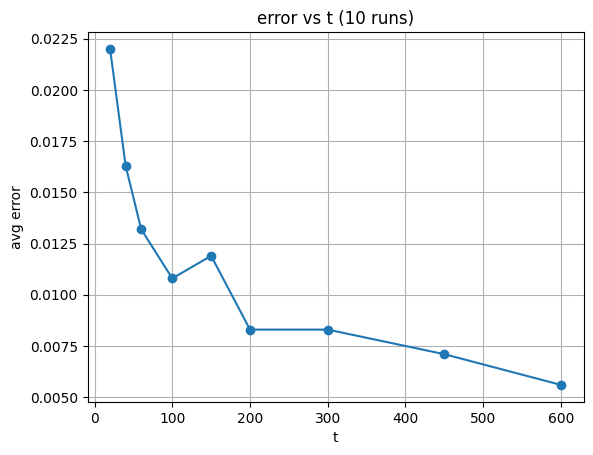

In [28]:
avg_errors = []
runs = 10
t_list = [20, 40, 60, 100, 150, 200, 300, 450, 600]

print(f"t        avg_error    avg_time(s)")
print('-' * 35)

for t in t_list:
    errs = []
    times = []
    for run in range(runs):
        random.seed(run)
        params = get_hash_params(t)
        t0 = time.time()
        s1 = get_signature(c3grams['D1'], params)
        s2 = get_signature(c3grams['D2'], params)
        errs.append(abs(sig_jaccard(s1, s2) - true_j))
        times.append(time.time() - t0)
    ae = round(sum(errs)/runs, 4)
    at = round(sum(times)/runs, 4)
    avg_errors.append(ae)
    print(f"{t:<8} {ae:<12} {at}")

plt.plot(t_list, avg_errors, marker='o')
plt.xlabel('t')
plt.ylabel('avg error')
plt.title('error vs t (10 runs)')
plt.grid(True)
plt.show()

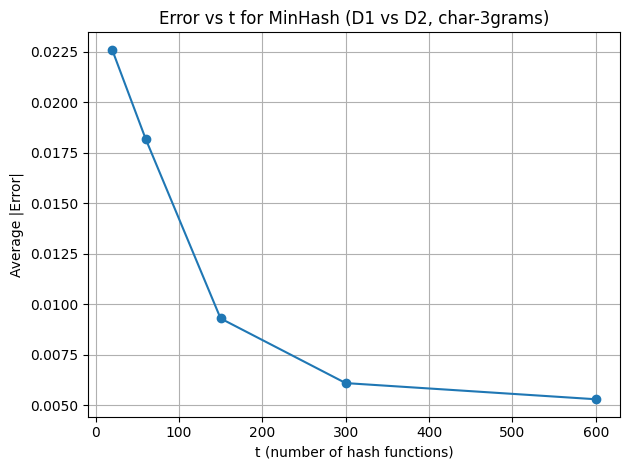

In [13]:
plt.plot(extra_t, avg_errors, marker='o')
plt.xlabel('t (number of hash functions)')
plt.ylabel('Average |Error|')
plt.title('Error vs t for MinHash (D1 vs D2, char-3grams)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Question 3 - LSH

### 3A - Find best b and r for t=160, T=0.7

In [32]:
t_lsh = 160
tau = 0.7

def s_curve(s, r, b):
    return 1 - (1 - s**b)**r

candidates = []
for r in range(1, t_lsh + 1):
    if t_lsh % r == 0:
        b = t_lsh // r
        prob_at_tau = s_curve(tau, r, b)
        candidates.append((r, b, round(prob_at_tau, 4)))

print(f"t=160, tau=0.7")
print(f"\nAll valid (r, b) combos:")
print(f"{'r':>5} {'b':>5} {'f(tau)':>10}")
print('-' * 25)
for r, b, p in candidates:
    print(f"{r:>5} {b:>5} {p:>10}")

# pick r,b where f(tau) is closest to 0.5 but from above
best = None
best_score = 999
for r, b, p in candidates:
    score = abs(p - 0.5)
    if p >= 0.5 and score < best_score:
        best_score = score
        best = (r, b, p)

print(f"\nBest choice: r={best[0]}, b={best[1]}, f(tau)={best[2]:.4f}")

t=160, tau=0.7

All valid (r, b) combos:
    r     b     f(tau)
-------------------------
    1   160        0.0
    2    80        0.0
    4    40        0.0
    5    32     0.0001
    8    20     0.0064
   10    16     0.0327
   16    10     0.3677
   20     8      0.695
   32     5     0.9972
   40     4        1.0
   80     2        1.0
  160     1        1.0

Best choice: r=20, b=8, f(tau)=0.6950


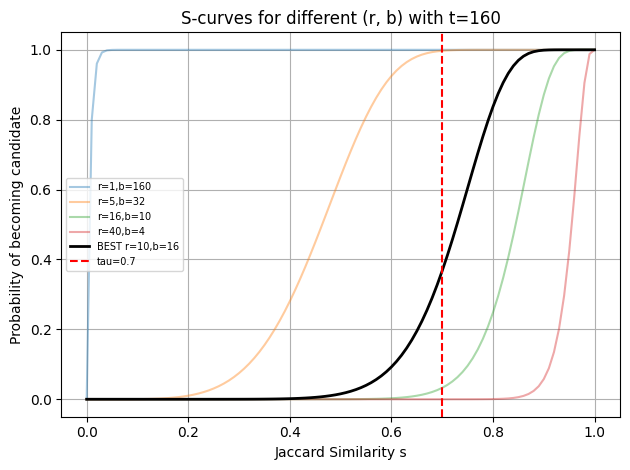

In [15]:
# plot s-curves for a few candidates
s_vals = [i/100 for i in range(101)]
r_best, b_best, _ = best

for r, b, _ in candidates[::3]:  # plot every 3rd
    probs = [s_curve(s, r, b) for s in s_vals]
    plt.plot(s_vals, probs, alpha=0.4, label=f'r={r},b={b}')

# highlight best
probs_best = [s_curve(s, r_best, b_best) for s in s_vals]
plt.plot(s_vals, probs_best, 'k-', linewidth=2, label=f'BEST r={r_best},b={b_best}')
plt.axvline(x=tau, color='red', linestyle='--', label=f'tau={tau}')
plt.xlabel('Jaccard Similarity s')
plt.ylabel('Probability of becoming candidate')
plt.title('S-curves for different (r, b) with t=160')
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

### 3B - Probability of each pair being estimated above tau

In [33]:
# probability of each pair being flagged using r=20, b=8
r_use, b_use, _ = best

print(f"Using r={r_use}, b={b_use}, tau={tau}\n")
print(f"{'Pair':<10} {'True Jaccard':>14} {'P(similarity > tau)':>20}")
print('-' * 46)

for d1, d2 in pairs:
    j = jaccard(c3grams[d1], c3grams[d2])
    prob = s_curve(j, r_use, b_use)
    print(f"{d1}-{d2:<7} {j:>14.4f} {prob:>20.4f}")

Using r=20, b=8, tau=0.7

Pair         True Jaccard  P(similarity > tau)
----------------------------------------------
D1-D2              0.9780               1.0000
D1-D3              0.5804               0.2282
D1-D4              0.3051               0.0015
D2-D3              0.5680               0.1959
D2-D4              0.3059               0.0015
D3-D4              0.3121               0.0018


## Question 4 - MinHashing on MovieLens 100k

In [ ]:
ml_path = r'C:\Users\esrnand\OneDrive - Ericsson\Desktop\IIT-PGD\Trimester 5\ml-100k\u.data'

user_movies = defaultdict(set)
with open(ml_path, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        uid = int(parts[0])
        mid = int(parts[1])
        user_movies[uid].add(mid)

print(f"Total users: {len(user_movies)}")
print(f"Total movies: {len(set(m for ms in user_movies.values() for m in ms))}")

all_users = sorted(user_movies.keys())

Total users: 943
Total movies: 1682


In [42]:
# exact jaccard for all user pairs - find pairs with similarity >= 0.5
# this is slow for 943 users so we do it smartly

t0 = time.time()

exact_similar_pairs = []  # pairs with J >= 0.5
exact_j = {}  # store all jaccard values

for i in range(len(all_users)):
    for j in range(i+1, len(all_users)):
        u1, u2 = all_users[i], all_users[j]
        s1 = user_movies[u1]
        s2 = user_movies[u2]
        inter = len(s1 & s2)
        union = len(s1 | s2)
        j_val = inter / union if union > 0 else 0.0
        exact_j[(u1, u2)] = j_val
        if j_val >= 0.5:
            exact_similar_pairs.append((u1, u2, round(j_val, 4)))

print(f"Pairs with exact Jaccard >= 0.5: {len(exact_similar_pairs)}")
print("\nSample pairs:")
for pair in exact_similar_pairs[:10]:
    print(f"  User {pair[0]} - User {pair[1]}: {pair[2]}")

Pairs with exact Jaccard >= 0.5: 10

Sample pairs:
  User 197 - User 600: 0.5
  User 197 - User 826: 0.513
  User 328 - User 788: 0.673
  User 408 - User 898: 0.8387
  User 451 - User 489: 0.5333
  User 489 - User 587: 0.6299
  User 554 - User 764: 0.517
  User 600 - User 826: 0.5455
  User 674 - User 879: 0.5217
  User 800 - User 879: 0.5


In [39]:
# minhash signatures for all users
PRIME_ML = 10007

def get_params_ml(t, seed=0):
    random.seed(seed)
    params = []
    seen = set()
    while len(params) < t:
        a = random.randint(1, PRIME_ML - 1)
        b = random.randint(0, PRIME_ML - 1)
        if (a, b) not in seen:
            seen.add((a, b))
            params.append((a, b))
    return params

def get_sig_ml(movie_set, params):
    ints = [m % PRIME_ML for m in movie_set]
    if not ints:
        return [PRIME_ML] * len(params)
    return [min((a*x + b) % PRIME_ML for x in ints) for a, b in params]

def count_fp_fn(approx_pairs_set, exact_pairs_set):
    fp = len(approx_pairs_set - exact_pairs_set)
    fn = len(exact_pairs_set - approx_pairs_set)
    return fp, fn

In [46]:
exact_set = set((u1, u2) for u1, u2, _ in exact_similar_pairs)

t_list = [50, 100, 200]
n_runs = 5

print(f"{'t':>5} {'Avg FP':>10} {'Avg FN':>10}")
print('-' * 30)

for t in t_list:
    fps, fns = [], []
    for run in range(n_runs):
        params = get_params_ml(t, seed=run)
        # build signatures
        sigs = {u: get_sig_ml(user_movies[u], params) for u in all_users}
        # find approx similar pairs
        approx_set = set()
        for i in range(len(all_users)):
            for j in range(i+1, len(all_users)):
                u1, u2 = all_users[i], all_users[j]
                s1, s2 = sigs[u1], sigs[u2]
                est = sum(a==b for a,b in zip(s1,s2)) / t
                if est >= 0.5:
                    approx_set.add((u1, u2))
        fp, fn = count_fp_fn(approx_set, exact_set)
        fps.append(fp); fns.append(fn)
    print(f"{t:>5} {sum(fps)/n_runs:>10.1f} {sum(fns)/n_runs:>10.1f}")

    print(f"\nApprox similar pairs for t={t} (last run):")
    
    for u1, u2 in sorted(approx_set):
        est = sum(a==b for a,b in zip(sigs[u1], sigs[u2])) / t
        print(f"  User {u1} - User {u2}: {round(est,4)}")

    t     Avg FP     Avg FN
------------------------------
   50      123.0        2.0

Approx similar pairs for t=50 (last run):
  User 13 - User 308: 0.56
  User 13 - User 435: 0.5
  User 15 - User 552: 0.5
  User 16 - User 823: 0.5
  User 26 - User 938: 0.5
  User 59 - User 234: 0.5
  User 59 - User 308: 0.5
  User 59 - User 561: 0.5
  User 64 - User 327: 0.5
  User 64 - User 561: 0.52
  User 64 - User 823: 0.52
  User 87 - User 533: 0.52
  User 92 - User 374: 0.52
  User 92 - User 457: 0.54
  User 94 - User 130: 0.52
  User 94 - User 293: 0.66
  User 94 - User 301: 0.5
  User 94 - User 417: 0.58
  User 94 - User 435: 0.6
  User 94 - User 472: 0.5
  User 94 - User 497: 0.5
  User 94 - User 682: 0.62
  User 94 - User 796: 0.5
  User 94 - User 880: 0.58
  User 94 - User 896: 0.52
  User 105 - User 808: 0.52
  User 109 - User 222: 0.56
  User 111 - User 673: 0.5
  User 111 - User 720: 0.5
  User 130 - User 435: 0.52
  User 145 - User 796: 0.5
  User 168 - User 703: 0.56
  User 170 - Us

In [48]:
for u1, u2, j in exact_similar_pairs:
    print(f"  User {u1} - User {u2}: {j}")

  User 197 - User 600: 0.5
  User 197 - User 826: 0.513
  User 328 - User 788: 0.673
  User 408 - User 898: 0.8387
  User 451 - User 489: 0.5333
  User 489 - User 587: 0.6299
  User 554 - User 764: 0.517
  User 600 - User 826: 0.5455
  User 674 - User 879: 0.5217
  User 800 - User 879: 0.5


## Question 5 - LSH on MovieLens

In [49]:
def lsh_candidates(sigs, all_users, r, b):
    # break signature into b bands of r rows each
    candidates = set()
    for band in range(b):
        buckets = defaultdict(list)
        for u in all_users:
            chunk = tuple(sigs[u][band*r : band*r + r])
            buckets[chunk].append(u)
        for bucket in buckets.values():
            if len(bucket) > 1:
                for u1, u2 in combinations(sorted(bucket), 2):
                    candidates.add((u1, u2))
    return candidates

def run_lsh_experiment(t, r, b, threshold, n_runs=5):
    # get exact pairs for given threshold
    exact = set((u1,u2) for (u1,u2), j in exact_j.items() if j >= threshold)
    fps, fns = [], []
    for run in range(n_runs):
        params = get_params_ml(t, seed=run)
        sigs = {u: get_sig_ml(user_movies[u], params) for u in all_users}
        cands = lsh_candidates(sigs, all_users, r, b)
        fp = len(cands - exact)
        fn = len(exact - cands)
        fps.append(fp); fns.append(fn)
    return round(sum(fps)/n_runs, 1), round(sum(fns)/n_runs, 1)

In [50]:
# experiments for similarity >= 0.6
configs = [
    (50,  5, 10),
    (100, 5, 20),
    (200, 5, 40),
    (200, 10, 20),
]

print("Threshold = 0.6")
print(f"{'t':>5} {'r':>4} {'b':>4} {'Avg FP':>10} {'Avg FN':>10}")
print('-' * 38)
for t, r, b in configs:
    fp, fn = run_lsh_experiment(t, r, b, threshold=0.6)
    print(f"{t:>5} {r:>4} {b:>4} {fp:>10} {fn:>10}")

Threshold = 0.6
    t    r    b     Avg FP     Avg FN
--------------------------------------
   50    5   10      659.0        0.6
  100    5   20     1091.8        0.0
  200    5   40     2268.0        0.0
  200   10   20        1.6        1.8


In [52]:
# same configs but threshold = 0.8
print("Threshold = 0.8")
print(f"{'t':>5} {'r':>4} {'b':>4} {'Avg FP':>10} {'Avg FN':>10}")
print('-' * 38)
for t, r, b in configs:
    fp, fn = run_lsh_experiment(t, r, b, threshold=0.8)
    print(f"{t:>5} {r:>4} {b:>4} {fp:>10} {fn:>10}")



Threshold = 0.8
    t    r    b     Avg FP     Avg FN
--------------------------------------
   50    5   10      660.4        0.0
  100    5   20     1093.8        0.0
  200    5   40     2270.0        0.0
  200   10   20        1.8        0.0
